In [2]:
# Step 1 - Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Step 2 - Load Dataset

In [3]:
movies = pd.read_csv("movie.csv")
ratings = pd.read_csv("rating.csv")

In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


In [6]:
# Step 3 — Explore Dataset

In [6]:
movies.shape

(27278, 3)

In [7]:
ratings.shape

(20000263, 4)

In [10]:
# Step 4 — Merge Datasets

In [8]:
df = ratings.merge(movies,on='movieId')
df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,2,3.5,2005-04-02 23:53:47,Jumanji (1995),Adventure|Children|Fantasy
1,5,2,3.0,1996-12-25 15:26:09,Jumanji (1995),Adventure|Children|Fantasy
2,13,2,3.0,1996-11-27 08:19:02,Jumanji (1995),Adventure|Children|Fantasy
3,29,2,3.0,1996-06-23 20:36:14,Jumanji (1995),Adventure|Children|Fantasy
4,34,2,3.0,1996-10-28 13:29:44,Jumanji (1995),Adventure|Children|Fantasy


In [12]:
# Step 5 - Data Cleaning

In [9]:
# Check Missing Values
df.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
title        0
genres       0
dtype: int64

In [10]:
# Remove Duplicates
df.drop_duplicates(inplace=True)

In [11]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 20000263 entries, 0 to 20000262
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  object 
 4   title      object 
 5   genres     object 
dtypes: float64(1), int64(2), object(3)
memory usage: 1.0+ GB


In [12]:
# Step 6 - Exploratory Data Analysis (EDA)

# Top Rated Movies

movie_ratings = df.groupby('title')['rating'].mean().sort_values(ascending=False)

movie_ratings.head(10)

title
Small Roads (2011)                                       5.0
Divorce (1945)                                           5.0
The Beautiful Story (1992)                               5.0
Into the Middle of Nowhere (2010)                        5.0
The Sea That Thinks (2000)                               5.0
The Wrecking Crew (2008)                                 5.0
Marihuana (1936)                                         5.0
No Distance Left to Run (2010)                           5.0
Stargate SG-1 Children of the Gods - Final Cut (2009)    5.0
This Thing With Sarah (2013)                             5.0
Name: rating, dtype: float64

In [13]:
# Most Popular Movies

popular_movies = df.groupby('title')['rating'].count().sort_values(ascending=False)

popular_movies.head(10)

title
Pulp Fiction (1994)                          67310
Forrest Gump (1994)                          66172
Shawshank Redemption, The (1994)             63366
Silence of the Lambs, The (1991)             63299
Jurassic Park (1993)                         59715
Star Wars: Episode IV - A New Hope (1977)    54502
Braveheart (1995)                            53769
Terminator 2: Judgment Day (1991)            52244
Matrix, The (1999)                           51334
Schindler's List (1993)                      50054
Name: rating, dtype: int64

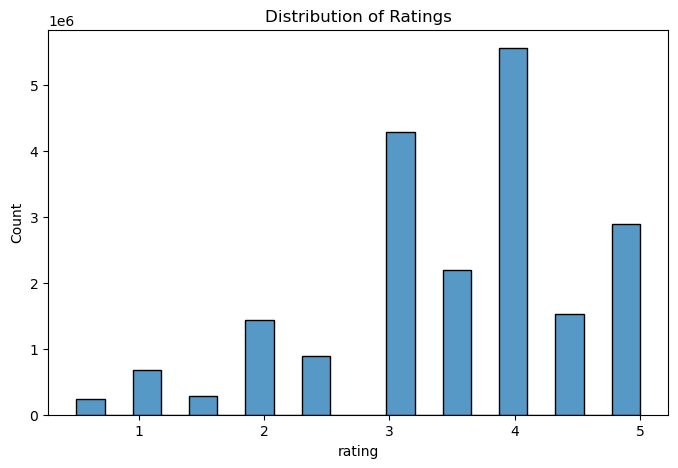

In [14]:
# Visualization — Rating Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=20)
plt.title("Distribution of Ratings")
plt.show()

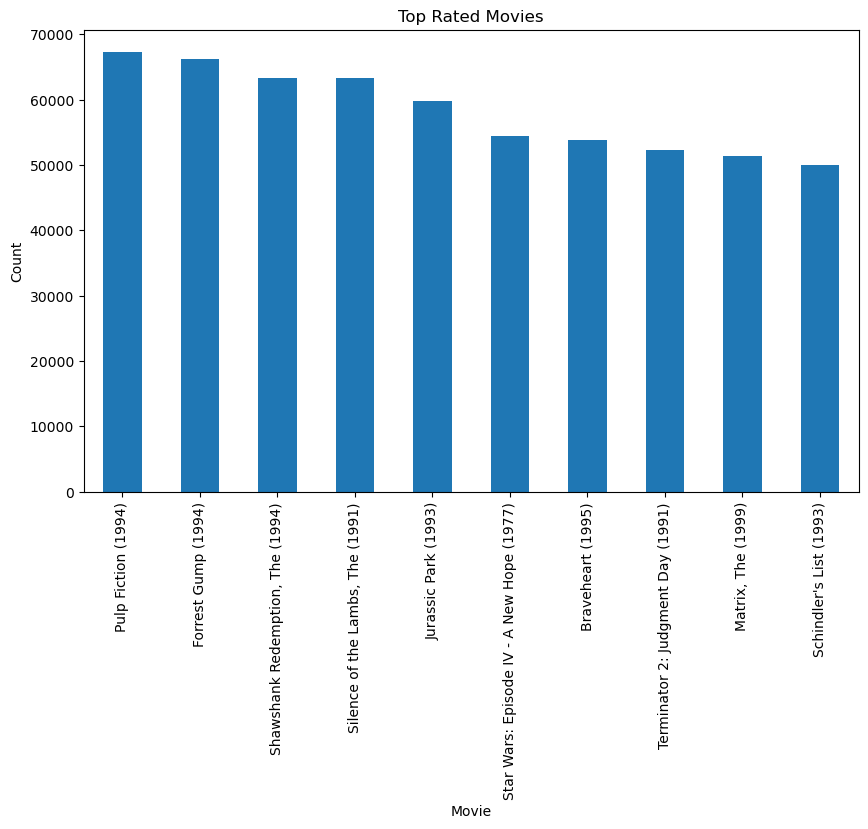

In [15]:
# Visualization — Most Rated Movies

top_movies = df['title'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_movies.plot(kind='bar')
plt.title("Top Rated Movies")
plt.xlabel("Movie")
plt.ylabel("Count")
plt.show()

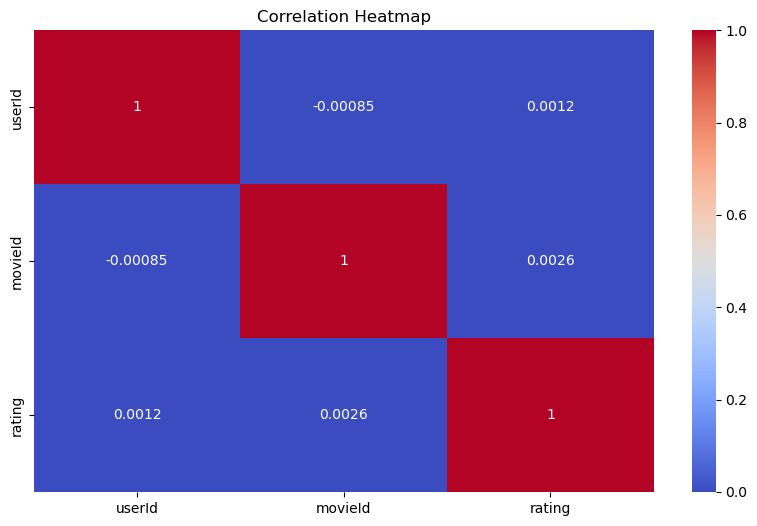

In [16]:
# Correlation Heatmap

plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [24]:
df_small = df.head(100000)

In [27]:
# Step 7 Collaborative Filtering

# Create User-Movie Matrix

movie_matrix = df_small.pivot_table(index='userId',
                              columns='title',
                              values='rating')

movie_matrix.head()

title,"City of Lost Children, The (Cité des enfants perdus, La) (1995)",Jumanji (1995),Seven (a.k.a. Se7en) (1995),Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
userId,,,,
1,3.5,3.5,3.5,3.5
3,NaN,NaN,NaN,4.0
4,NaN,NaN,NaN,1.0
5,NaN,3.0,NaN,NaN
8,NaN,NaN,5.0,NaN


In [29]:
# Replace Missing Values

movie_matrix.fillna(0, inplace=True)

In [30]:
movie_matrix.head()

title,"City of Lost Children, The (Cité des enfants perdus, La) (1995)",Jumanji (1995),Seven (a.k.a. Se7en) (1995),Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
userId,,,,
1,3.5,3.5,3.5,3.5
3,0.0,0.0,0.0,4.0
4,0.0,0.0,0.0,1.0
5,0.0,3.0,0.0,0.0
8,0.0,0.0,5.0,0.0


In [31]:
# Compute Cosine Similarity Matrix

similarity = cosine_similarity(movie_matrix.T)

In [32]:
# Create Similarity DataFrame

similarity_df = pd.DataFrame(
    similarity,
    index=movie_matrix.columns,
    columns=movie_matrix.columns
)

similarity_df.head()

title,"City of Lost Children, The (Cité des enfants perdus, La) (1995)",Jumanji (1995),Seven (a.k.a. Se7en) (1995),Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
title,,,,
"City of Lost Children, The (Cité des enfants perdus, La) (1995)",1.000000,0.145614,0.178505,0.328645
Jumanji (1995),0.145614,1.000000,0.288806,0.367801
Seven (a.k.a. Se7en) (1995),0.178505,0.288806,1.000000,0.431403
Twelve Monkeys (a.k.a. 12 Monkeys) (1995),0.328645,0.367801,0.431403,1.000000


In [36]:
# Step 8 Recommendation Logic

def recommend_movies(movie_name, num_recommendations=7):

    similar_scores = similarity_df[movie_name]\
                        .sort_values(ascending=False)

    recommended_movies = similar_scores.iloc[
                            1:num_recommendations+1
                         ]

    return recommended_movies

In [38]:
# Test Recommendation System

recommend_movies("Jumanji (1995)")

title
Twelve Monkeys (a.k.a. 12 Monkeys) (1995)                          0.367801
Seven (a.k.a. Se7en) (1995)                                        0.288806
City of Lost Children, The (Cité des enfants perdus, La) (1995)    0.145614
Name: Jumanji (1995), dtype: float64